<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/Moncef_Hiba_version0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
BASE_PATH = "/content/drive/MyDrive/compound"
IMAGE_PATH = os.path.join(BASE_PATH, "Image/aligned")
LABEL_PATH = os.path.join(BASE_PATH, "EmoLabel/list_patition_label.txt")

labels_dict = {}

with open(LABEL_PATH, "r") as f:
    for line in f:
        name, label = line.strip().split()
        labels_dict[name] = int(label) - 1  # 🔥 start from 0

In [4]:
train_images = []
test_images = []

for name in labels_dict.keys():
    if "train" in name:
        train_images.append(name)
    else:
        test_images.append(name)

print(len(train_images), len(test_images))

3162 792


In [5]:
class EmotionDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        real_name = img_name.replace(".jpg", "_aligned.jpg")
        img_path = os.path.join(IMAGE_PATH, real_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # Return black image + correct label to avoid crashing
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        label = labels_dict[img_name]
        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [7]:

train_data, val_data = train_test_split(train_images, test_size=0.2, random_state=42)

train_dataset = EmotionDataset(train_data, transform=train_transform)
val_dataset = EmotionDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True, num_workers=2)

In [8]:
labels_array = [labels_dict[x] for x in train_data]

num_classes = 14
class_weights = np.ones(num_classes)

unique_classes = np.unique(labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=labels_array
)

for i, c in enumerate(unique_classes):
    class_weights[c] = computed_weights[i]

weights = torch.tensor(class_weights, dtype=torch.float)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


In [10]:
model = models.resnet18(weights="DEFAULT")

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, 14)
)

model = model.to(device)

In [11]:

weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [12]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [13]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.3
)

In [14]:
num_epochs = 25
best_acc = 0

for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"✅ Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")

    scheduler.step(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print("🔥 Best model saved!")



🚀 Epoch 1/25
Batch 0/79 - Loss: 2.8419
Batch 20/79 - Loss: 2.7461
Batch 40/79 - Loss: 2.8941
Batch 60/79 - Loss: 2.6431
✅ Epoch 1 | Loss: 2.5559 | Acc: 19.41%
🔥 Best model saved!

🚀 Epoch 2/25
Batch 0/79 - Loss: 2.1323
Batch 20/79 - Loss: 2.1537
Batch 40/79 - Loss: 1.9930
Batch 60/79 - Loss: 2.0422
✅ Epoch 2 | Loss: 2.1731 | Acc: 21.55%
🔥 Best model saved!

🚀 Epoch 3/25
Batch 0/79 - Loss: 1.9659
Batch 20/79 - Loss: 2.0190
Batch 40/79 - Loss: 2.3902
Batch 60/79 - Loss: 1.8727
✅ Epoch 3 | Loss: 1.9754 | Acc: 24.34%
🔥 Best model saved!

🚀 Epoch 4/25
Batch 0/79 - Loss: 2.0774
Batch 20/79 - Loss: 1.6655
Batch 40/79 - Loss: 2.0097
Batch 60/79 - Loss: 1.8336
✅ Epoch 4 | Loss: 1.8100 | Acc: 22.86%

🚀 Epoch 5/25
Batch 0/79 - Loss: 1.4820
Batch 20/79 - Loss: 1.4288
Batch 40/79 - Loss: 1.4569
Batch 60/79 - Loss: 1.8086
✅ Epoch 5 | Loss: 1.6672 | Acc: 25.66%
🔥 Best model saved!

🚀 Epoch 6/25
Batch 0/79 - Loss: 1.5814
Batch 20/79 - Loss: 1.4267
Batch 40/79 - Loss: 1.3721
Batch 60/79 - Loss: 1.5100

In [15]:
class_names = [
    "Neutral", "Happy", "Sad", "Surprise",
    "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry",
    "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

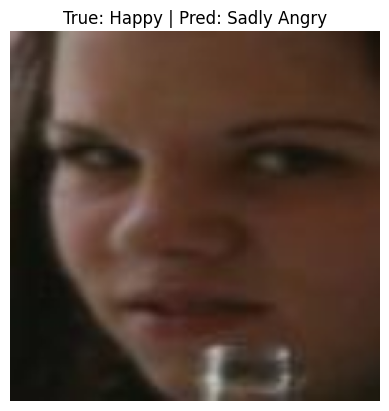

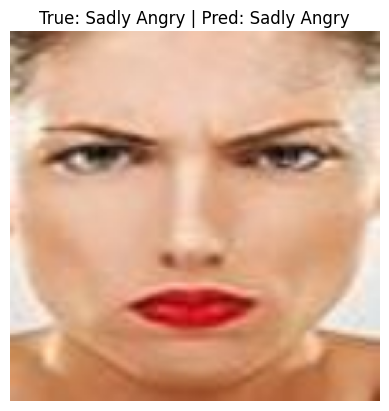

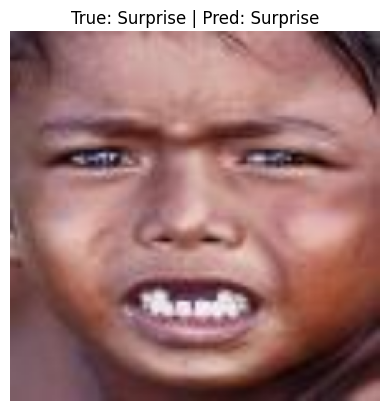

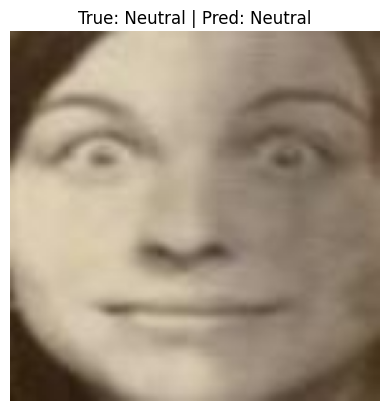

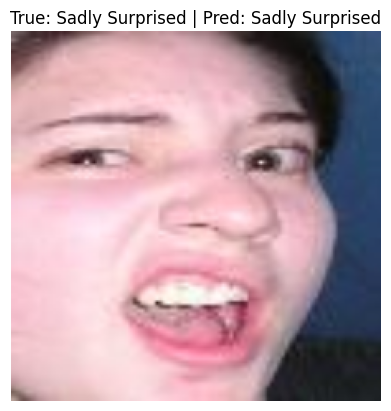

In [16]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

              precision    recall  f1-score   support

           0       0.59      0.46      0.52       100
           1       0.36      0.31      0.33        49
           2       0.23      0.13      0.17        23
           3       0.12      0.14      0.13        21
           4       0.05      0.06      0.06        17
           5       0.54      0.47      0.50       118
           6       0.27      0.32      0.29        19
           7       0.55      0.55      0.55        76
           8       0.30      0.38      0.33        29
           9       0.51      0.58      0.54       127
          10       0.21      0.34      0.26        29

    accuracy                           0.44       608
   macro avg       0.34      0.34      0.33       608
weighted avg       0.45      0.44      0.44       608



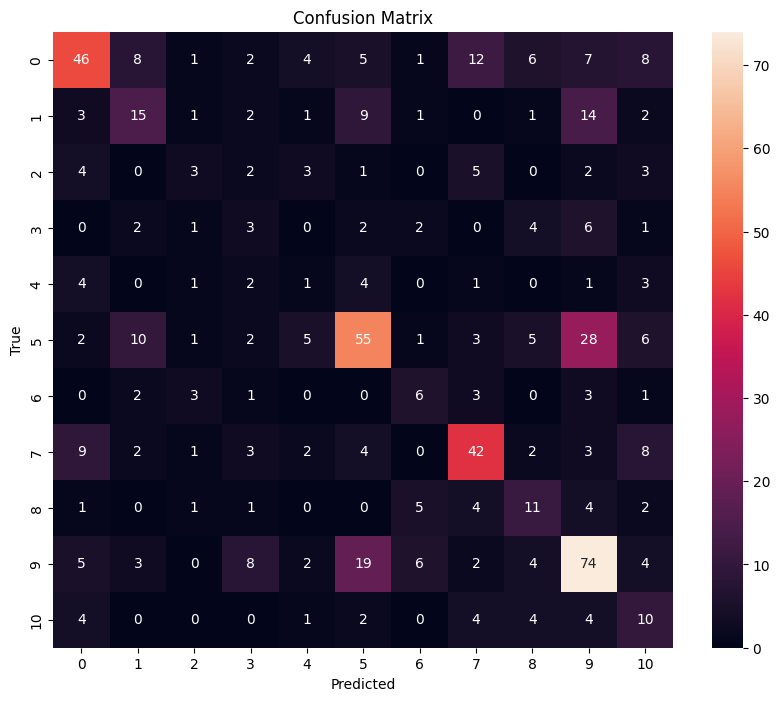

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [19]:
!pip install open_clip_torch streamlit

In [21]:
# ====================== INSTALLATION QLoRA ======================
!pip install -q bitsandbytes accelerate peft transformers

print("✅ bitsandbytes + peft + transformers installés pour QLoRA")

✅ bitsandbytes + peft + transformers installés pour QLoRA


In [23]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print("✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit")

✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit


In [25]:
from transformers import CLIPModel, CLIPProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from bitsandbytes.optim import AdamW8bit
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Create quantization config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# 2. Load CLIP model with quantization_config
model_clip = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 3. Freeze vision encoder
model_clip.vision_model.requires_grad_(False)

# 4. LoRA only on text encoder (task_type=None to avoid inputs_embeds error)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
    task_type=None
)

text_model = prepare_model_for_kbit_training(model_clip.text_model)
text_model = get_peft_model(text_model, lora_config)
model_clip.text_model = text_model

# Explicitly cast text_model to float16 to ensure consistent dtypes
model_clip.text_model.to(torch.float16)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

text_model.print_trainable_parameters()
print("✅ CLIP loaded with correct 4-bit quantization + QLoRA on text encoder")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


trainable params: 786,432 || all params: 63,952,384 || trainable%: 1.2297
✅ CLIP loaded with correct 4-bit quantization + QLoRA on text encoder


In [27]:
def predict_all_advanced(image):
    # CNN
    img = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # GradCAM
    cam = gradcam.generate(img, pred_cnn)

    img_np = np.array(image.resize((224,224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap)/255
    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # CLIP
    pred_clip, conf_clip = predict_clip(image)

    # Explanation
    explanation = generate_explanation(pred_cnn, cam)

    return (
        f"{class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.2f}%)",
        f"{class_names[pred_clip]} ({conf_clip*100:.2f}%)",
        superimposed,
        explanation
    )

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [33]:
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

In [35]:
def analyze_attention(cam):
    h = cam.shape[0]
    top = cam[:h//3]
    bottom = cam[2*h//3:]

    if np.mean(top) > np.mean(bottom):
        return "eyes"
    else:
        return "mouth"

def generate_explanation(pred, cam):
    focus = analyze_attention(cam)
    return f"Emotion '{class_names[pred]}' detected based on {focus} region."

In [37]:
optimizer_clip = AdamW8bit(model_clip.parameters(), lr=5e-5, weight_decay=0.01)

def train_clip_one_epoch(loader):
    model_clip.train()
    total_loss = 0.0
    num_batches = 0

    for batch_idx, (images, labels) in enumerate(loader):
        image_list = []
        for img_tensor in images:
            img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5) * 255
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            image_list.append(Image.fromarray(img_np))

        texts = [text_prompts[l.item()] for l in labels]

        inputs = processor(
            images=image_list,
            text=texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        outputs = model_clip(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

        logits = (image_embeds @ text_embeds.T) * 100.0
        loss = torch.nn.CrossEntropyLoss()(logits, torch.arange(len(images)).to(device))

        optimizer_clip.zero_grad()
        loss.backward()
        optimizer_clip.step()

        total_loss += loss.item()
        num_batches += 1

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")

    avg_loss = total_loss / num_batches
    print(f"✅ Epoch finished - Average Loss: {avg_loss:.4f}")
    return avg_loss

In [40]:
text_prompts = [
    "a person smiling with raised eyebrows",
    "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face",
    "a smiling person with slight disgust",
    "a sad person with fearful eyes",
    "an angry person with surprised expression",
    "a sad person with raised eyebrows",
    "a disgusted person with surprised face",
    "a person with wide eyes and open mouth",
    "an angry person with disgust expression",
    "a sad person with disgust expression",
    "a smiling person with anger",
    "a fearful person with anger",
    "a neutral face"
]

print("🔄 Starting QLoRA fine-tuning on CLIP text encoder...")

for epoch_ft in range(20):
    print(f"\n🚀 Fine-tuning Epoch {epoch_ft+1}/20")
    train_clip_one_epoch(train_loader)

model_clip.text_model.save_pretrained("/content/drive/MyDrive/clip_qlora_text_adapters")
print("🔥 QLoRA adapters saved successfully in Drive!")

🔄 Starting QLoRA fine-tuning on CLIP text encoder...

🚀 Fine-tuning Epoch 1/20
Batch 0/79 - Loss: 3.9043
Batch 20/79 - Loss: 3.3340
Batch 40/79 - Loss: 3.1152
Batch 60/79 - Loss: 3.0391
✅ Epoch finished - Average Loss: 3.1627

🚀 Fine-tuning Epoch 2/20
Batch 0/79 - Loss: 2.7441
Batch 20/79 - Loss: 2.7012
Batch 40/79 - Loss: 2.9492
Batch 60/79 - Loss: 2.8027
✅ Epoch finished - Average Loss: 2.8527

🚀 Fine-tuning Epoch 3/20
Batch 0/79 - Loss: 2.7031
Batch 20/79 - Loss: 2.9902
Batch 40/79 - Loss: 2.6797
Batch 60/79 - Loss: 2.6562
✅ Epoch finished - Average Loss: 2.7403

🚀 Fine-tuning Epoch 4/20
Batch 0/79 - Loss: 2.7480
Batch 20/79 - Loss: 2.5059
Batch 40/79 - Loss: 2.7910
Batch 60/79 - Loss: 3.0371
✅ Epoch finished - Average Loss: 2.6991

🚀 Fine-tuning Epoch 5/20
Batch 0/79 - Loss: 2.5098
Batch 20/79 - Loss: 2.6973
Batch 40/79 - Loss: 2.5605
Batch 60/79 - Loss: 2.6035
✅ Epoch finished - Average Loss: 2.6417

🚀 Fine-tuning Epoch 6/20
Batch 0/79 - Loss: 2.8281
Batch 20/79 - Loss: 2.7969
Bat

In [43]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Re-define predict_clip to be compatible with transformers.CLIPModel
def predict_clip(image):  # image = PIL Image
    inputs = processor(
        images=image,
        text=text_prompts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model_clip(**inputs)
        image_features = outputs.image_embeds
        text_features = outputs.text_embeds

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)

    pred = probs.argmax().item()
    return pred, probs[0][pred].item()

model.eval()
model_clip.eval()

y_true = []
y_pred_resnet = []
y_pred_clip = []

print("🚀 Évaluation sur le Validation Set...")

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        # ResNet prediction
        outputs = model(images)
        preds_resnet = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred_resnet.extend(preds_resnet)

        # CLIP QLoRA prediction (one by one)
        for i in range(images.size(0)):
            img_tensor = images[i]
            img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5) * 255
            img_pil = Image.fromarray(img_np.astype(np.uint8))
            pred_clip, conf = predict_clip(img_pil)
            y_pred_clip.append(pred_clip)

        y_true.extend(labels.cpu().numpy())

# Métriques
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_clip = accuracy_score(y_true, y_pred_clip)
f1_resnet = f1_score(y_true, y_pred_resnet, average='macro')
f1_clip = f1_score(y_true, y_pred_clip, average='macro')

print(f"\n📊 Résultats finaux :")
print(f"ResNet18      → Accuracy: {acc_resnet:.4f} | Macro F1: {f1_resnet:.4f}")
print(f"CLIP + QLoRA  → Accuracy: {acc_clip:.4f} | Macro F1: {f1_clip:.4f}")

comparison = pd.DataFrame({
    "Modèle": ["ResNet18 (Fine-tuned)", "CLIP ViT-B/32 + QLoRA"],
    "Accuracy": [acc_resnet, acc_clip],
    "Macro F1-Score": [f1_resnet, f1_clip]
})
display(comparison.round(4))

🚀 Évaluation sur le Validation Set...

📊 Résultats finaux :
ResNet18      → Accuracy: 0.4375 | Macro F1: 0.3345
CLIP + QLoRA  → Accuracy: 0.1562 | Macro F1: 0.1624


,Modèle,Accuracy,Macro F1-Score
0,ResNet18 (Fine-tuned),0.4375,0.3345
1,CLIP ViT-B/32 + QLoRA,0.1562,0.1624


🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...
✅ CLIP Evaluation terminée !
                       precision    recall  f1-score   support

              Neutral       0.75      0.15      0.25       100
                Happy       0.73      0.22      0.34        49
                  Sad       0.20      0.04      0.07        23
             Surprise       0.00      0.00      0.00        21
                 Fear       0.00      0.00      0.00        17
              Disgust       0.82      0.08      0.14       118
                Angry       0.64      0.37      0.47        19
             Contempt       0.62      0.30      0.41        76
    Happily Surprised       0.18      0.10      0.13        29
          Sadly Angry       0.71      0.16      0.26       127
      Sadly Surprised       0.21      0.21      0.21        29
  Fearfully Surprised       0.00      0.00      0.00         0
    Angrily Surprised       0.00      0.00      0.00         0
Disgustedly Surprised      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

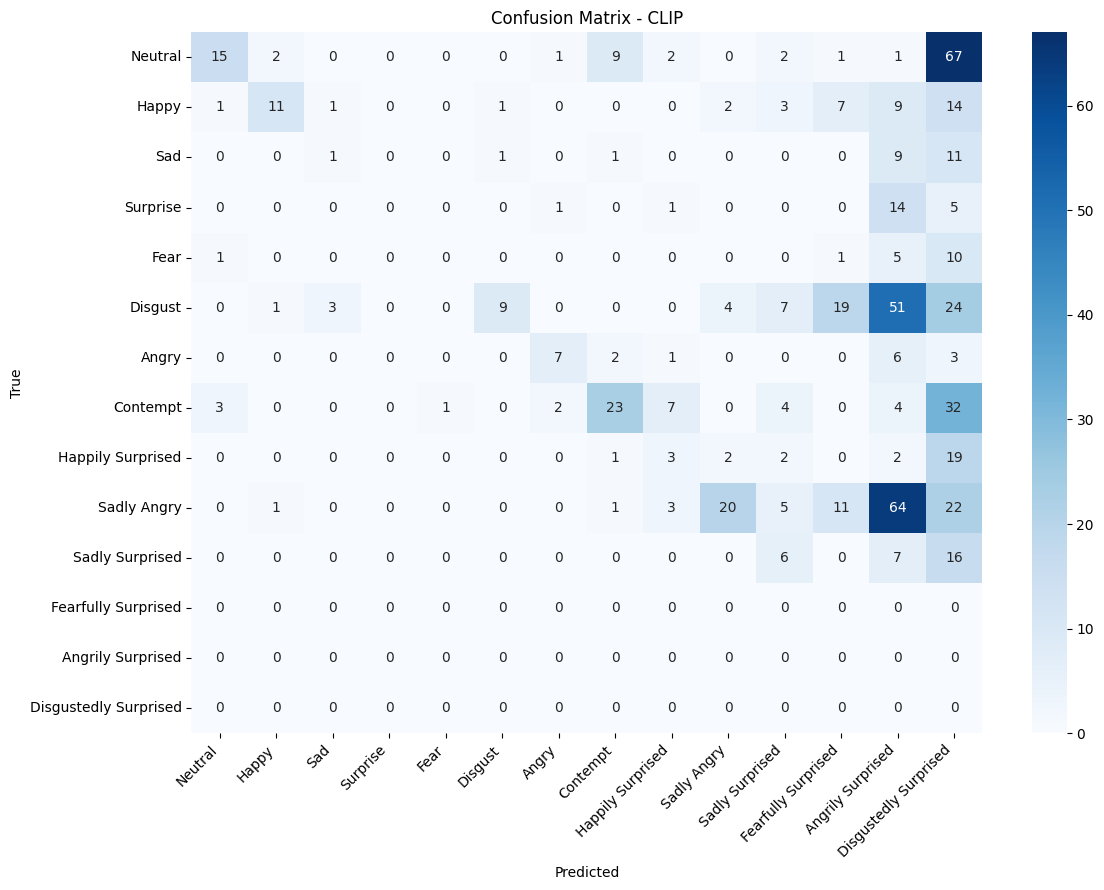

Average CLIP confidence: 0.0747


In [44]:
# ====================== ÉVALUATION CLIP SUR VAL DATASET ======================
print("🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...")

y_true_clip = []
y_pred_clip = []
clip_confidences = []

model_clip.eval()

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        for j in range(images.size(0)):  # une image à la fois car predict_clip prend PIL
            img_tensor = images[j]
            # reconvertir en PIL pour predict_clip
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * 0.5) + 0.5
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))

            pred, conf = predict_clip(img_pil)
            y_pred_clip.append(pred)
            y_true_clip.append(labels[j].item())
            clip_confidences.append(conf)

print("✅ CLIP Evaluation terminée !")

# Rapport
print(classification_report(y_true_clip, y_pred_clip, labels=np.arange(num_classes), target_names=class_names))

# Confusion matrix CLIP
cm_clip = confusion_matrix(y_true_clip, y_pred_clip)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_clip, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - CLIP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Average CLIP confidence: {np.mean(clip_confidences):.4f}")

🖼️ Test visuel sur 6 images du validation set
Image 1: True = Disgust | ResNet = Sadly Surprised | CLIP = Disgustedly Surprised


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Image 2: True = Sadly Angry | ResNet = Surprise | CLIP = Angrily Surprised
Image 3: True = Happy | ResNet = Surprise | CLIP = Angrily Surprised
Image 4: True = Disgust | ResNet = Disgust | CLIP = Disgustedly Surprised
Image 5: True = Neutral | ResNet = Disgust | CLIP = Disgustedly Surprised
Image 6: True = Sadly Angry | ResNet = Sadly Angry | CLIP = Angrily Surprised


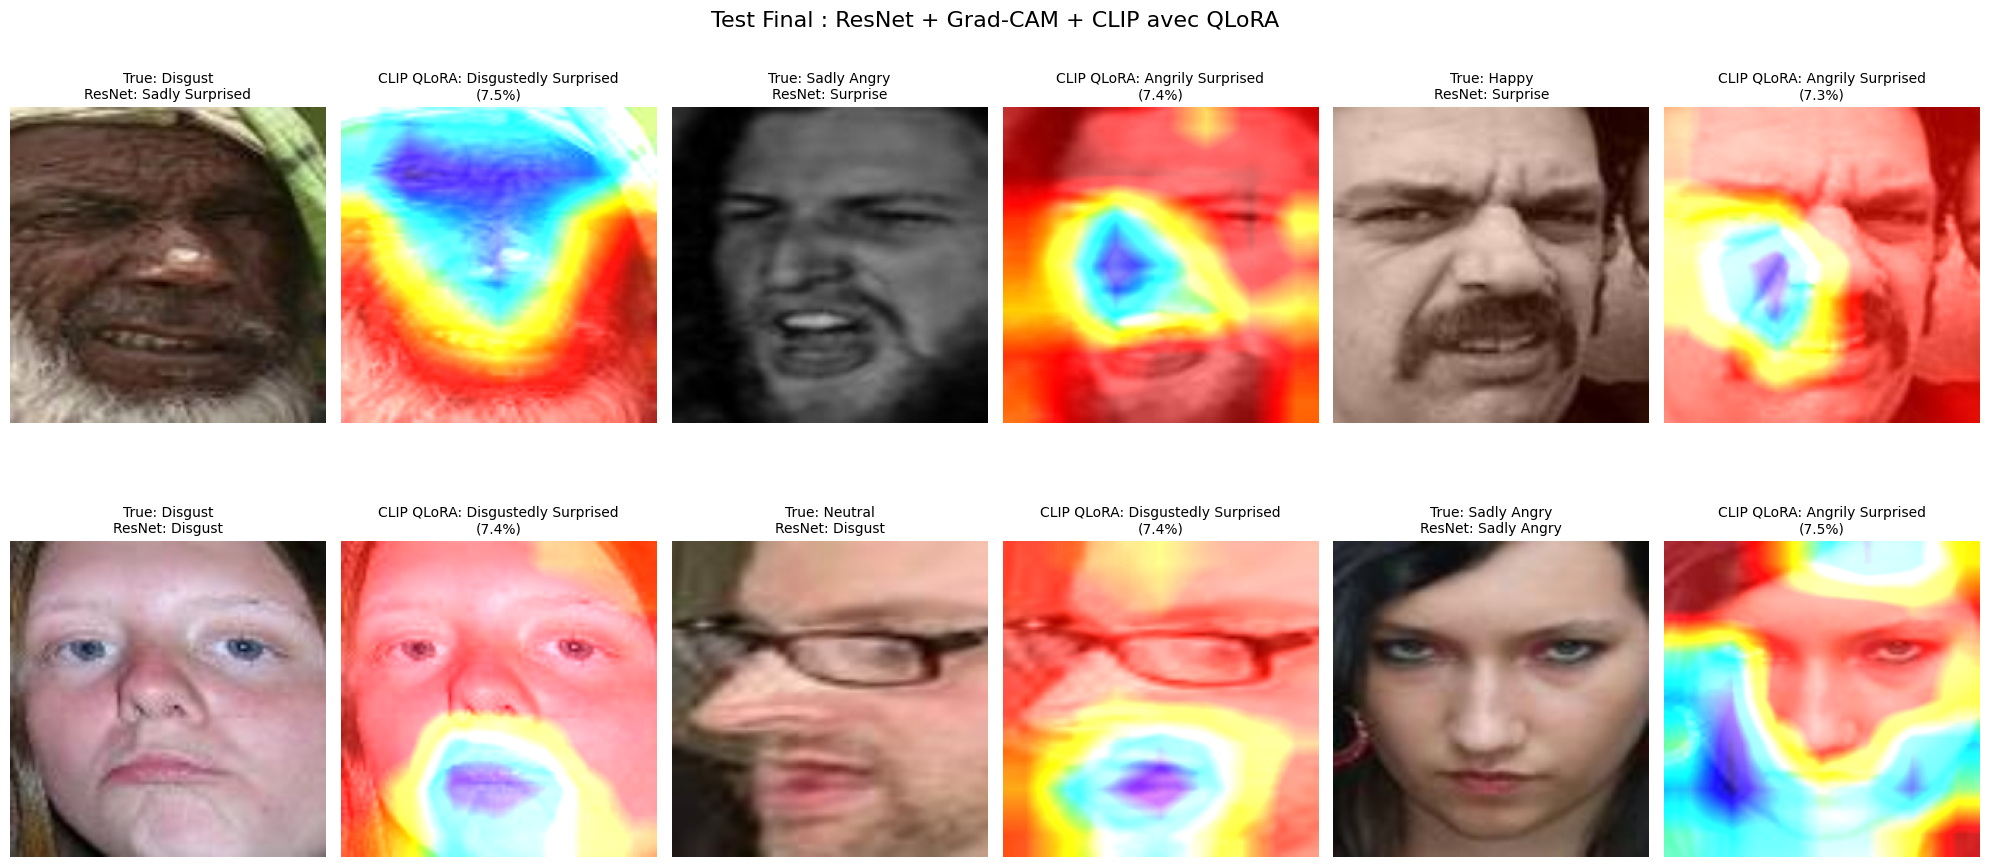

In [45]:
print("🖼️ Test visuel sur 6 images du validation set")

indices = random.sample(range(len(val_dataset)), 6)
plt.figure(figsize=(20, 14))

for plot_idx, idx in enumerate(indices):
    img_tensor, true_label = val_dataset[idx]

    # Convert to PIL for CLIP
    img_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5) * 255
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)
    img_pil = Image.fromarray(img_np)

    # ResNet + Grad-CAM
    input_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred_cnn = torch.argmax(output, dim=1).item()
    cam = gradcam.generate(input_tensor, pred_cnn)

    # CLIP QLoRA
    pred_clip_idx, conf_clip = predict_clip(img_pil)

    explanation = generate_explanation(pred_cnn, cam)

    # Superimposed image
    img_display = np.array(img_pil.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = np.clip(heatmap + np.float32(img_display) / 255.0, 0, 1)

    # Plot
    plt.subplot(3, 6, plot_idx*2 + 1)
    plt.imshow(img_display)
    plt.title(f"True: {class_names[true_label]}\nResNet: {class_names[pred_cnn]}", fontsize=10)
    plt.axis("off")

    plt.subplot(3, 6, plot_idx*2 + 2)
    plt.imshow(superimposed)
    plt.title(f"CLIP QLoRA: {class_names[pred_clip_idx]}\n({conf_clip*100:.1f}%)", fontsize=10)
    plt.axis("off")

    print(f"Image {plot_idx+1}: True = {class_names[true_label]} | ResNet = {class_names[pred_cnn]} | CLIP = {class_names[pred_clip_idx]}")

plt.suptitle("Test Final : ResNet + Grad-CAM + CLIP avec QLoRA", fontsize=16)
plt.tight_layout()
plt.show()

In [46]:
def compare_predictions(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

    print("Prediction ResNet:", pred.item())

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred.item())

    plt.imshow(cam, cmap='jet')
    plt.title("Zones importantes (Grad-CAM)")
    plt.axis('off')
    plt.show()

In [47]:
def generate_explanation(pred_class, focus_area):

    emotion = class_names[pred_class]

    if focus_area == "eyes":
        focus_text = "the eyes"
    elif focus_area == "mouth":
        focus_text = "the mouth"
    else:
        focus_text = "the central facial region"

    explanation = f"The model predicts '{emotion}' because it focuses mainly on {focus_text}."

    return explanation

In [48]:
def predict_all_advanced_fixed(image):
    """Version corrigée et sécurisée de predict_all_advanced (utilise tes fonctions existantes)"""
    # CNN
    img_tensor = val_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # Grad-CAM
    cam = gradcam.generate(img_tensor, pred_cnn)

    img_np = np.array(image.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_np) / 255.0
    superimposed = superimposed / np.max(superimposed)

    # CLIP
    pred_clip, conf_clip = predict_clip(image)

    # Explication (ta fonction originale)
    explanation = generate_explanation(pred_cnn, cam)

    return (
        f"{class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.2f}%)",
        f"{class_names[pred_clip]} ({conf_clip*100:.2f}%)",
        superimposed,
        explanation
    )
print("✅ predict_all_advanced_fixed créée (utilise-la dans Streamlit)")

✅ predict_all_advanced_fixed créée (utilise-la dans Streamlit)


In [49]:
def show_gradcam_with_text(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # 🔥 analyse zones
    focus_area = analyze_attention(cam)

    # 🔥 génération texte
    explanation = generate_explanation(pred_class, focus_area)

    # image originale
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # affichage
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    # 🔥 texte final
    print("🧠 Explanation:")
    print(explanation)


In [50]:
def full_test(img_path):
    model.eval()

    # preprocess
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    top3_prob, top3_class = torch.topk(probs, 3)

    pred_class = top3_class[0][0].item()

    print("Top 3 classes:", top3_class)
    print("Probabilities:", top3_prob)

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # affichage
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    return pred_class

🚀 Test CLIP + Grad-CAM sur : /content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg


/tmp/ipykernel_63661/774212701.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


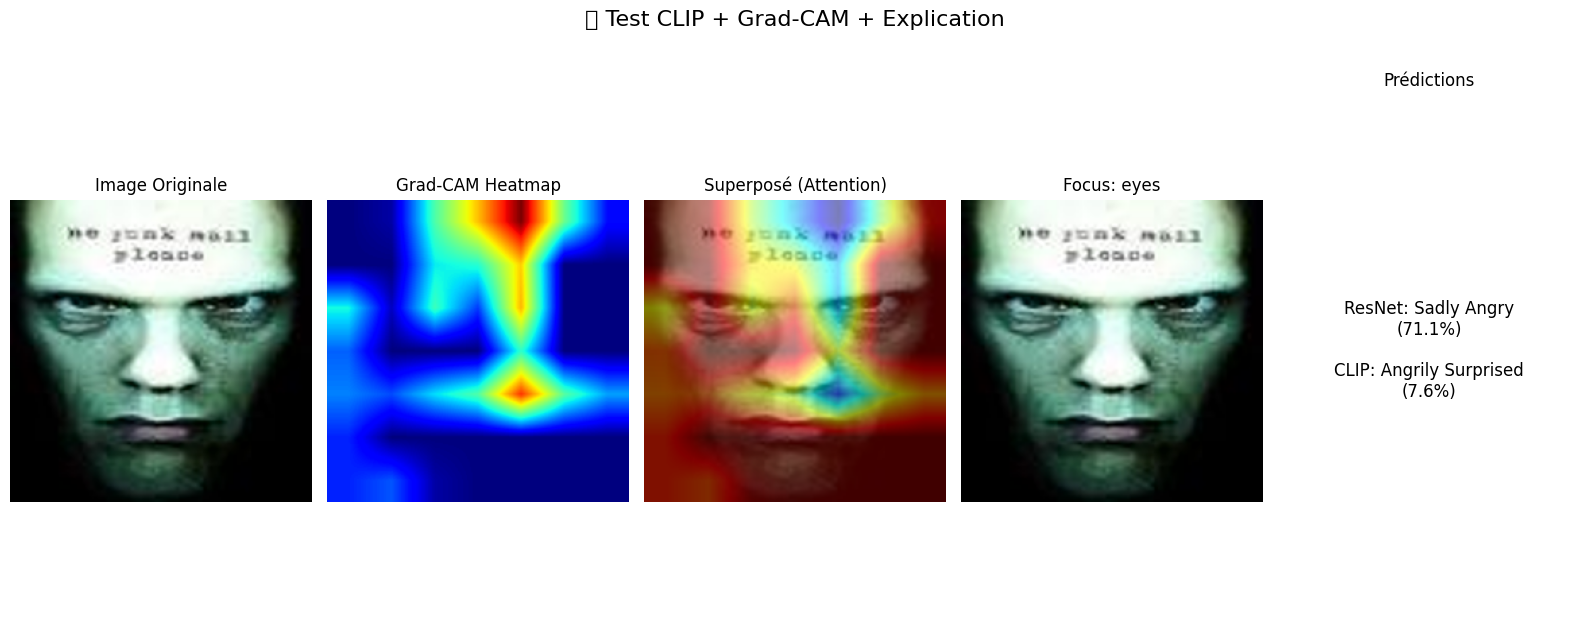

🧠 Explication : The model predicts 'Sadly Angry' because it focuses mainly on the eyes.
📍 Zone d'attention détectée : eyes
📊 Confiance CLIP : 7.57%


In [51]:
# ====================== TEST CLIP + GRAD-CAM SUR UNE SEULE IMAGE (VERSION CORRIGÉE) ======================
test_image_path = "/content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg"

print(f"🚀 Test CLIP + Grad-CAM sur : {test_image_path}")

# Chargement de l'image
test_img = Image.open(test_image_path).convert("RGB")

# 1. Prédiction ResNet + Grad-CAM
img_tensor = val_transform(test_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_cnn = torch.argmax(probs, dim=1).item()

cam = gradcam.generate(img_tensor, pred_cnn)

# 2. Prédiction CLIP
pred_clip_idx, conf_clip = predict_clip(test_img)
pred_clip_name = class_names[pred_clip_idx]

# 3. Analyse de la zone d'attention
focus_area = analyze_attention(cam)

# 4. Explication (maintenant corrigée)
explanation = generate_explanation(pred_cnn, focus_area)

# 5. Affichage
img_np = np.array(test_img.resize((224, 224)))

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255.0
superimposed = heatmap + np.float32(img_np) / 255.0
superimposed = superimposed / np.max(superimposed)

plt.figure(figsize=(16, 6))

plt.subplot(1, 5, 1)
plt.imshow(img_np)
plt.title("Image Originale")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(superimposed)
plt.title("Superposé (Attention)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(img_np)
plt.title(f"Focus: {focus_area}")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.text(0.5, 0.5, f"ResNet: {class_names[pred_cnn]}\n({probs[0][pred_cnn]*100:.1f}%)\n\n"
                    f"CLIP: {pred_clip_name}\n({conf_clip*100:.1f}%)",
         ha='center', va='center', fontsize=12)
plt.title("Prédictions")
plt.axis("off")

plt.suptitle("✅ Test CLIP + Grad-CAM + Explication", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("🧠 Explication :", explanation)
print(f"📍 Zone d'attention détectée : {focus_area}")
print(f"📊 Confiance CLIP : {conf_clip*100:.2f}%")

In [52]:
# ====================== TABLEAU COMPARAISON RESNET vs CLIP ======================
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

print("📊 Calcul des métriques sur tout le Validation Set...\n")

y_true = []
y_pred_resnet = []
y_pred_clip = []

model.eval()
model_clip.eval()

with torch.no_grad():
    for images, labels in val_loader:
        # ResNet
        images = images.to(device)
        outputs = model(images)
        preds_resnet = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred_resnet.extend(preds_resnet)

        # CLIP (une par une car il prend PIL)
        for i in range(images.size(0)):
            img_tensor = images[i]
            img_np = (img_tensor.permute(1,2,0).cpu().numpy() * 0.5 + 0.5) * 255
            img_pil = Image.fromarray(img_np.astype(np.uint8))
            pred_clip, _ = predict_clip(img_pil)
            y_pred_clip.append(pred_clip)

        y_true.extend(labels.cpu().numpy())

# Métriques
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_clip = accuracy_score(y_true, y_pred_clip)
f1_resnet = f1_score(y_true, y_pred_resnet, average='macro')
f1_clip = f1_score(y_true, y_pred_clip, average='macro')

print(f"ResNet  → Accuracy: {acc_resnet:.4f} | Macro F1: {f1_resnet:.4f}")
print(f"CLIP    → Accuracy: {acc_clip:.4f} | Macro F1: {f1_clip:.4f}")

# Tableau
comparison = pd.DataFrame({
    "Modèle": ["ResNet18 (Fine-tuned)", "CLIP (ViT-B/32)"],
    "Accuracy": [acc_resnet, acc_clip],
    "Macro F1-Score": [f1_resnet, f1_clip]
})
display(comparison.round(4))

📊 Calcul des métriques sur tout le Validation Set...

ResNet  → Accuracy: 0.4375 | Macro F1: 0.3345
CLIP    → Accuracy: 0.1562 | Macro F1: 0.1624


,Modèle,Accuracy,Macro F1-Score
0,ResNet18 (Fine-tuned),0.4375,0.3345
1,CLIP (ViT-B/32),0.1562,0.1624


In [53]:
# ====================== VERSION AMÉLIORÉE AVEC MEILLEURE ANALYSE GRADCAM ======================
%%writefile app.py

import streamlit as st
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import open_clip

st.set_page_config(page_title="FER-CE Hiba", layout="centered")

st.title("🎯 FER-CE : Reconnaissance Émotions Composées")
st.caption("ResNet18 + CLIP + Grad-CAM — RAF-CE")

class_names = [
    "Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry", "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

@st.cache_resource
def load_models():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.6),
        nn.Linear(512, 14)
    )
    model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
    model.to(device)
    model.eval()

    model_clip, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    model_clip.to(device)
    model_clip.eval()

    return model, model_clip, preprocess, device

model, model_clip, preprocess, device = load_models()

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

text_prompts = [
    "a person smiling with raised eyebrows", "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face", "a smiling person with slight disgust",
    "a sad person with fearful eyes", "an angry person with surprised expression",
    "a sad person with raised eyebrows", "a disgusted person with surprised face",
    "a person with wide eyes and open mouth", "an angry person with disgust expression",
    "a sad person with disgust expression", "a smiling person with anger",
    "a fearful person with anger", "a neutral face"
]
text_tokens = open_clip.tokenize(text_prompts).to(device)

def predict_clip(image):
    image_input = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text_tokens)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)
    pred = probs.argmax().item()
    return pred, probs[0][pred].item()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()
        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()
        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()
        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

target_layer = model.layer4[-1] if hasattr(model.layer4, '__iter__') else model.layer4
gradcam = GradCAM(model, target_layer)

# ====================== ANALYSE D'ATTENTION AMÉLIORÉE ======================
def analyze_attention(cam):
    h, w = cam.shape
    # Diviser en 3 zones : sourcils/yeux | nez | bouche
    top = np.mean(cam[:int(h*0.35)])      # sourcils + yeux
    middle = np.mean(cam[int(h*0.35):int(h*0.65)])
    bottom = np.mean(cam[int(h*0.65):])   # bouche

    if top > bottom and top > middle:
        return "eyes and eyebrows"
    elif bottom > top and bottom > middle:
        return "mouth and lower face"
    else:
        return "central face (nose/eyes area)"

def generate_explanation(pred_class, cam):
    emotion = class_names[pred_class]
    focus = analyze_attention(cam)
    return f"'{emotion}' - Focus on {focus}."

# ====================== INTERFACE ======================
uploaded_file = st.file_uploader("Charge une image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Image chargée", use_column_width=True)

    img_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    cam = gradcam.generate(img_tensor, pred_cnn)
    pred_clip, conf_clip = predict_clip(image)
    explanation = generate_explanation(pred_cnn, cam)

    col1, col2 = st.columns(2)
    with col1:
        st.success(f"ResNet: {class_names[pred_cnn]} ({probs[0][pred_cnn]*100:.1f}%)")
    with col2:
        st.success(f"CLIP: {class_names[pred_clip]} ({conf_clip*100:.1f}%)")

    st.subheader("🔥 Grad-CAM - Zones d’attention")

    img_np = np.array(image.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_np) / 255.0
    superimposed = np.clip(superimposed / np.max(superimposed), 0, 1)

    superimposed_pil = Image.fromarray((superimposed * 255).astype(np.uint8))

    st.image(superimposed_pil, caption="Superimposed Grad-CAM (Attention du modèle)", use_column_width=True)

    st.info(explanation)

st.sidebar.success("Modèles chargés avec succès")

Overwriting app.py


In [54]:
!npm install -g localtunnel
print("✅ localtunnel installé avec npm")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙✅ localtunnel installé avec npm


In [55]:
!curl -s https://ipv4.icanhazip.com

34.16.129.27


In [56]:
# Arrêter les anciens processus
!pkill -f streamlit
!pkill -f localtunnel

# Lancer Streamlit en arrière-plan
!streamlit run app.py &>/content/streamlit_logs.txt &
!sleep 8
print("✅ Streamlit lancé en arrière-plan")

# Lancer le tunnel
!npx localtunnel --port 8501 --subdomain fer-ce-hiba-final

✅ Streamlit lancé en arrière-plan
⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://fer-ce-hiba-final.loca.lt
^C


In [77]:
import nbformat
import os

# 🔍 Try possible locations
possible_paths = [
    "/content/Moncef_Hiba_clean0.1.ipynb",
    "/content/drive/MyDrive/Colab Notebooks/Moncef_Hiba_clean0.1.ipynb",
    "/content/drive/MyDrive/Colab Notebooks/Moncef_Hiba_version0.1.ipynb",
    "/content/FER-CE-Project/Moncef_Hiba_version0.1.ipynb"
]

file_path = None

for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError("❌ Notebook not found. Check your file name and path.")

print("✅ Using file:", file_path)

# 📖 Read notebook
with open(file_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# 🔥 REMOVE widgets globally
nb["metadata"].pop("widgets", None)

for cell in nb["cells"]:
    # clean metadata
    cell["metadata"] = {}

    # clean outputs
    if "outputs" in cell:
        for output in cell["outputs"]:
            if "data" in output:
                output["data"].pop("application/vnd.jupyter.widget-view+json", None)
                output["data"].pop("application/vnd.jupyter.widget-state+json", None)

# 💾 Save clean notebook
clean_path = "/content/FINAL_READY.ipynb"

with open(clean_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("✅ READY:", clean_path)

✅ Using file: /content/drive/MyDrive/Colab Notebooks/Moncef_Hiba_clean0.1.ipynb
✅ READY: /content/FINAL_READY.ipynb
